# 02 — Baseline Model: SVM + HOG Features
## Deepfake Face Detection

**Model:** Support Vector Machine với HOG (Histogram of Oriented Gradients) features  
**Mục tiêu:** Xác lập baseline — con số tối thiểu mà các model phức tạp hơn phải vượt qua  
**Library:** scikit-learn, scikit-image

In [17]:
import sys, os, warnings
warnings.filterwarnings("ignore")

# ── Tìm project root ──────────────────────────────────────────────────────────
def _find_root():
    d = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.isdir(os.path.join(d, "src")):
            return d
        d = os.path.dirname(d)
    raise FileNotFoundError("Không tìm thấy project root")

ROOT     = _find_root()
REPORTS  = os.path.join(ROOT, "reports")
os.makedirs(REPORTS, exist_ok=True)
sys.path.insert(0, os.path.join(ROOT, "src"))

# ── Thư viện ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Import từ src/
from dataset  import build_dataframe, split_dataframe, load_images_numpy
from evaluate import evaluate_model

print("✅ Import xong")
print(f"   Root    : {ROOT}")
print(f"   Reports : {REPORTS}")

✅ Import xong
   Root    : e:\HK4\Sta_ML\DO_ÂNNANANANNA\deepfake-detection
   Reports : e:\HK4\Sta_ML\DO_ÂNNANANANNA\deepfake-detection\reports


## 1. Load dữ liệu

Dùng lại `dataset.py` đã viết sẵn.  
Với SVM ta dùng **64×64** thay vì 224×224 vì:
- HOG trên 224×224 → ~35,000 features/ảnh → 14,000 ảnh → **~7GB RAM**
- HOG trên 64×64  → ~3,500 features/ảnh  → 14,000 ảnh → **~700MB RAM** ✓
- Baseline không cần độ phân giải cao — SVM không học fine-grained texture

In [2]:
DATA_DIR = os.path.join(ROOT, "data", "raw")
IMG_SIZE = (64, 64)   # nhỏ hơn để SVM không bị OOM

# Build & split
df = build_dataframe(DATA_DIR)
train_df, val_df, test_df = split_dataframe(df)

print(f"Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}")
print(f"Label train: {train_df['label'].value_counts().to_dict()}")

Train : 14,000  |  Val : 3,000  |  Test : 3,000
Label train: {0: 7000, 1: 7000}


In [ ]:
print("⏳ Đang load train set...")
X_train_raw, y_train = load_images_numpy(train_df, img_size=IMG_SIZE)

print("⏳ Đang load test set...")
X_test_raw,  y_test  = load_images_numpy(test_df,  img_size=IMG_SIZE)

print(f"\nX_train shape : {X_train_raw.shape}")   # (14000, 64, 64, 3)
print(f"y_train shape : {y_train.shape}")          # (14000,)
print(f"Pixel range   : [{X_train_raw.min():.1f}, {X_train_raw.max():.1f}]")

⏳ Đang load train set...
⏳ Đang load test set...


NameError: name 'cc' is not defined

## 2. Trích xuất HOG Features

HOG = Histogram of Oriented Gradients  
Thay vì đưa 64×64×3 = 12,288 pixel số thô vào SVM,  
ta tính **hướng và cường độ của cạnh** trong từng vùng nhỏ của ảnh.

Tham số:
- `orientations=9` : chia 360° thành 9 hướng (mỗi bin = 40°, nhưng HOG dùng 0-180° nên mỗi bin = 20°)
- `pixels_per_cell=(8,8)` : mỗi ô 8×8 pixel → tính 1 histogram 9 giá trị
- `cells_per_block=(2,2)` : chuẩn hoá mỗi khối 2×2 ô để bất biến với ánh sáng
- `channel_axis=-1` : báo cho hàm biết chiều thứ 3 là kênh màu RGB

In [7]:
from tqdm import tqdm
import time

def extract_hog(X, img_size=(64, 64)):
    """
    Input : X shape (N, H, W, 3)
    Output: feature matrix shape (N, n_features)
    """
    features = []
    for img in tqdm(X, desc="Extracting HOG", unit="img"):
        feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            channel_axis=-1,
        )
        features.append(feat)
    return np.array(features)

print("⏳ HOG — train set...")
X_train_hog = extract_hog(X_train_raw)

print("⏳ HOG — test set...")
X_test_hog  = extract_hog(X_test_raw)

print(f"\nX_train_hog shape : {X_train_hog.shape}")
print(f"Mỗi ảnh           : {X_train_hog.shape[1]:,} features")

⏳ HOG — train set...


Extracting HOG: 100%|██████████| 14000/14000 [00:14<00:00, 965.47img/s]


⏳ HOG — test set...


Extracting HOG: 100%|██████████| 3000/3000 [00:03<00:00, 971.24img/s]


X_train_hog shape : (14000, 1764)
Mỗi ảnh           : 1,764 features


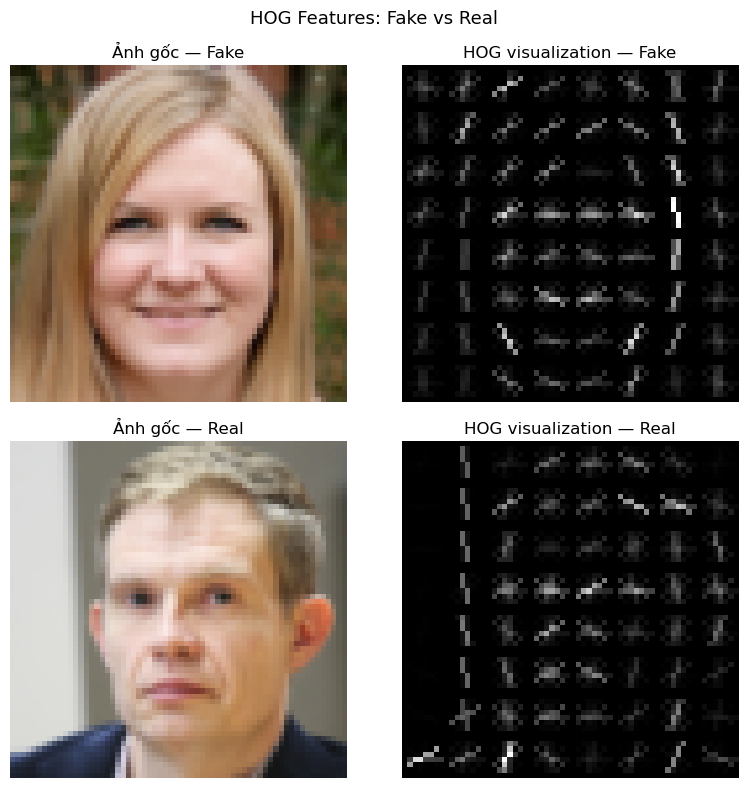

In [8]:
# Xem HOG của 1 ảnh fake và 1 ảnh real
from skimage.feature import hog as hog_viz
from skimage import exposure

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for row, label_val, label_name in [(0, 0, "Fake"), (1, 1, "Real")]:
    idx = np.where(y_train == label_val)[0][0]
    img = X_train_raw[idx]

    _, hog_img = hog_viz(
        img,
        orientations=9, pixels_per_cell=(8,8),
        cells_per_block=(2,2), channel_axis=-1,
        visualize=True,
    )
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Ảnh gốc — {label_name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(hog_img, cmap="gray")
    axes[row, 1].set_title(f"HOG visualization — {label_name}")
    axes[row, 1].axis("off")

plt.suptitle("HOG Features: Fake vs Real", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "hog_visualization.png"), dpi=150)
plt.show()

In [ ]:
# StandardScaler: đưa mỗi feature về mean=0, std=1
# Tại sao cần? HOG features ở các chiều có scale khác nhau
# SVM nhạy với scale → cần chuẩn hoá trước
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_test_scaled  = scaler.transform(X_test_hog)

print("⏳ Đang train SVM...")
print("   (SVM không có progress bar — đây là bình thường)")
print("   Máy vẫn đang chạy nếu thấy dấu * ở góc tab Jupyter\n")

t0  = time.time()
svm = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
elapsed = time.time() - t0

print(f"✅ Train xong! Thời gian: {elapsed:.1f} giây ({elapsed/60:.1f} phút)")

⏳ Đang train SVM...
   (SVM không có progress bar — đây là bình thường)
   Máy vẫn đang chạy nếu thấy dấu * ở góc tab Jupyter

✅ Train xong! Thời gian: 1800.2 giây (30.0 phút)



  KẾT QUẢ: SVM + HOG
  Accuracy  : 0.7230  (72.30%)
  Precision : 0.7237
  Recall    : 0.7213
  F1-score  : 0.7225
  ROC-AUC   : 0.8007


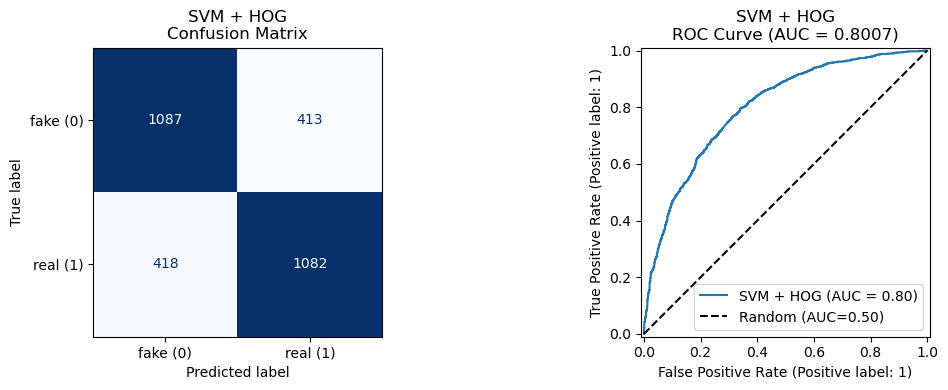

  Đã lưu biểu đồ → e:\HK4\Sta_ML\DO_ÂNNANANANNA\deepfake-detection\reports\svm___hog_evaluation.png



In [12]:
# Dự đoán trên test set
y_pred = svm.predict(X_test_scaled)
y_prob = svm.predict_proba(X_test_scaled)[:, 1]  # xác suất lớp "real"

# Gọi evaluate_model từ src/evaluate.py — in metrics + lưu biểu đồ
results_svm = evaluate_model(
    y_true      = y_test,
    y_pred      = y_pred,
    y_prob      = y_prob,
    model_name  = "SVM + HOG",
    save_dir    = REPORTS,
)

## 3. Lưu kết quả

In [14]:
import pandas as pd

# Lưu kết quả vào CSV để sau này so sánh tất cả model
RESULTS_CSV = os.path.join(REPORTS, "all_results.csv")

# results_svm là dict trả về từ evaluate_model()
df_results = pd.DataFrame([results_svm])

# Nếu file đã tồn tại (từ lần chạy trước) → append, không ghi đè
if os.path.exists(RESULTS_CSV):
    df_existing = pd.read_csv(RESULTS_CSV)
    # Xoá dòng cũ của cùng model nếu có (tránh duplicate)
    df_existing = df_existing[df_existing["model"] != results_svm["model"]]
    df_results = pd.concat([df_existing, df_results], ignore_index=True)

df_results.to_csv(RESULTS_CSV, index=False)
print("✅ Đã lưu kết quả vào reports/all_results.csv")
print(df_results.to_string(index=False))

✅ Đã lưu kết quả vào reports/all_results.csv
    model  accuracy  precision  recall     f1  roc_auc
SVM + HOG     0.723     0.7237  0.7213 0.7225   0.8007


In [18]:
# ── Thử nghiệm tinh chỉnh SVM ──────────────────────────────────────

# Lấy 4,000 ảnh train thay vì 14,000 → mỗi lần train ~3 phút
TUNE_SIZE = 4000
idx = np.random.RandomState(42).choice(len(X_train_hog), TUNE_SIZE, replace=False)
X_tune = X_train_scaled[idx]
y_tune = y_train[idx]

# Danh sách hyperparameter muốn thử
experiments = [
    {"kernel": "rbf",    "C": 0.1},   # C nhỏ → margin rộng, có thể underfit
    {"kernel": "rbf",    "C": 1.0},   # ← đây là kết quả đã có (baseline)
    {"kernel": "rbf",    "C": 10.0},  # C lớn → margin hẹp, có thể overfit
    {"kernel": "linear", "C": 1.0},   # kernel khác — so sánh
]

tune_results = []

for params in experiments:
    print(f"⏳ Đang thử: kernel={params['kernel']}, C={params['C']}")
    m = SVC(**params, probability=True, random_state=42)
    m.fit(X_tune, y_tune)

    yp   = m.predict(X_test_scaled)
    yprob = m.predict_proba(X_test_scaled)[:, 1]

    tune_results.append({
        "kernel"  : params["kernel"],
        "C"       : params["C"],
        "accuracy": round(accuracy_score(y_test, yp), 4),
        "f1"      : round(f1_score(y_test, yp), 4),
        "roc_auc" : round(roc_auc_score(y_test, yprob), 4),
        "train_size": TUNE_SIZE,
    })
    print(f"   Accuracy={tune_results[-1]['accuracy']:.4f}  AUC={tune_results[-1]['roc_auc']:.4f}")

df_tune = pd.DataFrame(tune_results)
print("\n=== BẢNG SO SÁNH HYPERPARAMETER SVM ===")
print(df_tune.to_string(index=False))

# Lưu vào reports để dùng trong báo cáo
df_tune.to_csv(os.path.join(REPORTS, "svm_tuning.csv"), index=False)
print("\n✅ Đã lưu → reports/svm_tuning.csv")

⏳ Đang thử: kernel=rbf, C=0.1
   Accuracy=0.6387  AUC=0.7025
⏳ Đang thử: kernel=rbf, C=1.0
   Accuracy=0.6913  AUC=0.7618
⏳ Đang thử: kernel=rbf, C=10.0
   Accuracy=0.6950  AUC=0.7675
⏳ Đang thử: kernel=linear, C=1.0
   Accuracy=0.6040  AUC=0.6355

=== BẢNG SO SÁNH HYPERPARAMETER SVM ===
kernel    C  accuracy     f1  roc_auc  train_size
   rbf  0.1    0.6387 0.6191   0.7025        4000
   rbf  1.0    0.6913 0.6844   0.7618        4000
   rbf 10.0    0.6950 0.6933   0.7675        4000
linear  1.0    0.6040 0.6008   0.6355        4000

✅ Đã lưu → reports/svm_tuning.csv
